In [30]:
import os, random
import re
import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import load_model
import tensorflow.keras.metrics as metrics
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform

In [2]:
# -----------------------------------------------------------------
# Set working directory
wkdir = r"C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01transcriptome/00data/"
os.chdir(wkdir)

# -----------------------------------------------------------------
# File paths
#uthbCounts = r"00uthb_genecounts-08152025.csv.gz"
vabbCounts = r"00vabb_genecounts-08152025.csv.gz"

# Reading annotation
#uthbAnnot = r"00uthb_annotation-08152025.csv.gz"
vabbAnnot = r"00vabb_annotation-08152025.csv.gz"

# -----------------------------------------------------------------
# Read gzipped CSVs
#expr_uthb = pd.read_csv(uthbCounts, index_col=0, compression='gzip')
expr_vabb = pd.read_csv(vabbCounts, index_col=0, compression='gzip')
#annot_uthb = pd.read_csv(uthbAnnot, index_col=0, compression='gzip')
annot_vabb = pd.read_csv(vabbAnnot, index_col=0, compression='gzip')

# -----------------------------------------------------------------

In [3]:
# -----------------------------------------------------------------
# Loading metadata
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/00vabb/00PhenoMeta_trainclock-07272025.csv"
phenoData = pd.read_csv(phenoPath)
# Create suffixes
suffixes = ["_9", "_24", "_25", "_11"]
# Replicate and modify pheno_data
phenoData = pd.concat([
    phenoData.assign(SampleID="Sample" + phenoData["SampleID"].astype(str) + suffix)
    for suffix in suffixes
], ignore_index=True)
phenoData.shape
# -----------------------------------------------------------------

(564, 6)

In [4]:
# Load cell types and SVAs
cells = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/05celltype-08042025/00vabb_cellprop_svas-08042025.csv")
cells = cells.rename(columns={'name': 'SampleID'})
cells.shape

(551, 17)

In [5]:
# Merge in sequence after conversion
merged_df_com = pd.merge(phenoData, cells, on='SampleID')
meta = merged_df_com
meta.shape

(546, 22)

In [6]:
# -----------------------------------------------------------------
# Subset meta to only required columns
meta = meta[['SampleID', 'Sex', 'PMI', 'RIN', 'AgeDeath', 'ast', 'end', 'mic', 'neu', 'oli', 'opc', 'W_1', 'W_2']]
# Columns not to scale
exclude_cols = ['SampleID', 'Sex', 'AgeDeath']

# Identify columns to scale
cols_to_scale = [col for col in meta.columns if col not in exclude_cols]

# Initialize scaler
scaler = StandardScaler(with_mean=True, with_std=True)

# Scale selected columns
meta_scaled = meta.copy()
meta_scaled[cols_to_scale] = scaler.fit_transform(meta_scaled[cols_to_scale])
# Set SampleID as index
meta_scaled = meta_scaled.set_index('SampleID')
meta_scaled.head()

,Sex,PMI,RIN,AgeDeath,ast,end,mic,neu,oli,opc,W_1,W_2
SampleID,,,,,,,,,,,,
Sample5205_9,Male,1.344314,1.002963,51,-0.985183,-0.718509,-0.410640,-0.266188,-0.664003,-0.952803,-0.108106,-0.192520
Sample5228_9,Female,0.646458,-1.095190,58,-0.633027,-0.839082,-0.563833,-0.297959,-0.658491,-0.931297,-0.037179,-0.167703
Sample5286_9,Female,0.879077,-1.394926,44,0.176086,0.233682,2.609995,0.242871,0.001352,0.322115,21.817682,2.574510
Sample5287_9,Male,1.189235,0.303579,40,-0.590237,-0.925822,-0.597451,-0.393386,-0.697382,-1.016107,-0.065587,-0.121521
Sample5323_9,Male,0.181221,-0.395805,35,-1.143411,-0.719600,-0.327777,-0.647711,-0.780717,-0.976483,-0.044045,-0.022014


In [7]:
# -----------------------------------------------------------------
# Function to clean sample names
def clean_sample_name(name):
    # Match "Sample<number><letters><number>" and replace with "Sample<number>_<number>"
    return re.sub(r"(Sample\d+)[A-Za-z]+(\d+)", r"\1_\2", name)

# Apply to a DataFrame
# Example: expr_uthb.columns = [clean_sample_name(c) for c in expr_uthb.columns]
expr_vabb.columns = [clean_sample_name(c) for c in expr_vabb.columns]
expr_vabb.head()
# -----------------------------------------------------------------

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000284662,28,24,11,21,9,12,0,2,9,32,...,1,3,23,38,56,29,15,11,31,20
ENSG00000186827,10,16,9,5,2,9,9,17,3,45,...,11,6,33,7,91,26,8,10,73,29
ENSG00000186891,8,32,12,2,5,15,13,34,23,48,...,33,8,43,6,80,25,19,37,57,23
ENSG00000160072,529,1015,372,358,497,286,674,1161,504,1667,...,480,505,1633,714,4695,1521,573,959,3142,1684
ENSG00000041988,65,144,102,82,60,114,174,279,122,312,...,196,188,321,196,1103,375,108,259,729,373


In [8]:
# -----------------------------------------------------------------
# Define a function for the estimation FPKM of transcriptome data
def counts_to_fpkm(counts: pd.DataFrame, gene_lengths: pd.Series, lengths_in: str = "bp") -> pd.DataFrame:
    """
    Convert raw counts to FPKM.
    counts: genes x samples
    gene_lengths: length per gene (index aligned to counts)
    lengths_in: 'bp' or 'kb'
    """
    assert set(counts.index).issubset(set(gene_lengths.index)), "Gene lengths missing for some genes"  
    # Convert lengths to kilobases
    L = gene_lengths.loc[counts.index].astype(float)
    if lengths_in == "bp":
        L = L / 1e3
    elif lengths_in != "kb":
        raise ValueError("lengths_in must be 'bp' or 'kb'")
        
    # RPK: counts / length_kb
    rpk = counts.divide(L, axis=0)
    
    # FPKM: RPK / (total_mapped_reads_in_millions)
    per_sample_scaler = counts.sum(axis=0) / 1e6
    fpkm = rpk.divide(per_sample_scaler, axis=1)
    
    return fpkm

# -----------------------------------------------------------------
# Define a function for the estimation of gene lengths
def extract_gene_bounds(df: pd.DataFrame, start_col='Start', end_col='End'):
    """
    Extract first start and last end for genes where Start/End columns may contain multiple positions separated by ';'.
    
    Args:
        df: DataFrame with at least 'GeneID', start_col, end_col
        start_col: name of the start column
        end_col: name of the end column
        
    Returns:
        DataFrame with 'GeneID', 'Start', 'End', 'GeneLength'
    """
    starts = []
    ends = []
    for s, e in zip(df[start_col], df[end_col]):
        # Split by ',' and convert to int
        start_vals = [int(x) for x in str(s).split(';') if x.strip().isdigit()]
        end_vals   = [int(x) for x in str(e).split(';') if x.strip().isdigit()]
        if start_vals and end_vals:
            starts.append(min(start_vals))  # first start = smallest
            ends.append(max(end_vals))      # last end = largest
        else:
            starts.append(None)
            ends.append(None)
    
    result = pd.DataFrame({
        'GeneID': df['GeneID'],
        'Start': starts,
        'End': ends
    })
    
    # Compute gene length
    result['GeneLength'] = result['End'] - result['Start'] + 1
    return result

In [9]:
# -----------------------------------------------------------------
# Transforming to FPKM
gene_info_vabb = extract_gene_bounds(annot_vabb)
# Make Series: index = GeneID, values = GeneLength
gene_lengths = pd.Series(gene_info_vabb["GeneLength"].values, index=gene_info_vabb["GeneID"])
fpkm_matrix = counts_to_fpkm(expr_vabb, gene_lengths, lengths_in="bp")
fpkm_matrix.shape

(60605, 551)

In [10]:
# -----------------------------------------------------------------
# Filtering to FPKM
# To avoid the influence of low count genes on the analysis result, genes with more than 30% samples having count per million (CPM) less than one were filtered out
mfilter = (fpkm_matrix < 1).sum(axis=1) / fpkm_matrix.shape[1] <= 0.3
fpkm_matrix = fpkm_matrix.loc[mfilter]  # assign back
fpkm_matrix.shape

(9105, 551)

In [11]:
# -----------------------------------------------------------------
# Standardize by gene (rows)
scaler = StandardScaler(with_mean=True, with_std=True)
expr_z = pd.DataFrame(
    scaler.fit_transform(fpkm_matrix.T).T,  # transpose -> scale -> transpose back
    index=fpkm_matrix.index,  # keep gene names
    columns=fpkm_matrix.columns  # keep sample names
)
expr_z.head()

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000160072,1.032523,1.711955,-0.085869,0.626116,0.142356,-1.534350,1.616278,1.263234,-0.076390,1.512895,...,-1.172818,-1.516864,0.582666,-1.194454,0.640007,0.532361,0.335098,-0.217445,0.644238,0.889257
ENSG00000225972,4.563008,2.811983,-0.264908,-0.292317,1.492488,1.045303,-0.526877,-0.460963,-0.016767,0.109340,...,-0.615557,-0.222504,-0.559921,-0.181519,-0.507210,-0.528148,-0.594211,-0.462490,-0.424670,-0.453273
ENSG00000224315,1.687359,1.046504,0.066807,-0.904123,-0.380758,-0.732082,-0.120664,0.096232,0.582366,0.223664,...,-0.987097,-0.856729,0.539175,0.351821,-0.847716,-0.410237,-1.351098,-0.682342,-0.145540,-0.445355
ENSG00000198744,1.343346,0.391138,0.306707,-0.097394,2.434571,0.206976,-0.331683,-0.358510,0.240591,0.187385,...,-0.827569,-0.682511,-0.790172,-0.369185,-0.779362,-0.781348,-0.841667,-0.805819,-0.807733,-0.750103
ENSG00000225630,0.955431,0.034720,-0.030795,-0.499710,2.005468,-0.202936,-1.023479,-0.962707,0.275962,0.120231,...,-0.572983,1.244179,-0.235424,1.823509,-0.246167,-0.595604,-0.130808,-0.240961,-0.328370,-0.490384


In [12]:
# -----------------------------------------------------------------
# Subsetting to only unique samples
# Example: columns in your expression matrix
columns = expr_z.columns  # expr is your genes x samples DataFrame
# Extract the prefix before the underscore
prefixes = [col.split('_')[0] for col in columns]
# Create a DataFrame to associate columns with prefixes
col_df = pd.DataFrame({'col': columns, 'prefix': prefixes})

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
# Sample one column per prefix
unique_cols = col_df.groupby('prefix')['col'].apply(lambda x: np.random.choice(x)).values
# Subset your expression matrix
expr_unique = expr_z[unique_cols]
# Check
print(expr_unique.shape)
print(expr_z.shape)

(9105, 143)
(9105, 551)


In [13]:
# -----------------------------------------------------------------
# Columns that were selected
unique_cols_set = set(unique_cols)
# Columns that were not selected
excluded_cols = [col for col in expr_z.columns if col not in unique_cols_set]
# Check
print("Number of selected columns:", len(unique_cols))
print("Number of excluded columns:", len(excluded_cols))
# Optional: print first 10 excluded columns
print("Excluded columns:", excluded_cols[:10])

Number of selected columns: 143
Number of excluded columns: 408
Excluded columns: ['Sample10027_24', 'Sample10027_9', 'Sample1093_24', 'Sample1093_9', 'Sample1124_9', 'Sample1185_24', 'Sample1185_9', 'Sample1201_24', 'Sample1201_9', 'Sample1221_24']


In [14]:
# ------------------------------
# Align samples
common_samples = expr_unique.columns.intersection(meta_scaled.index)
expr_unique = expr_unique[common_samples]
meta_scaled2 = meta_scaled.loc[common_samples]
print(expr_unique.shape)
print(meta_scaled2.shape)

(9105, 141)
(141, 12)


In [15]:
# ------------------------------
# Load the Genes from the Elastic Net with cross-validation
# ------------------------------
# Extract age
# Extract age as a Series
y_age = meta_scaled2['AgeDeath']  # replace 'Age' with the exact column name if different
y_age = pd.Series(y_age, name='AgeDeath')  # ensures it's a Series with a name

# Shape should be (samples, genes)
X = expr_unique.T
y = y_age.loc[X.index]

# Load the intercept CSV
selected_gene_names = pd.read_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv",
    index_col=0
)
selected_gene_names = selected_gene_names.index

# Subset to genes in elastic net
selected_gene_names_index = pd.Index(selected_gene_names)

# Filter expr_excluded to only genes present in expr_z
expr_selected_filtered = expr_z[common_samples].loc[selected_gene_names_index.intersection(expr_z.index)]
X_selected = expr_selected_filtered.T
print(X_selected.shape)

(141, 232)


In [31]:
# ------------------------------
# Training Deep Learning Model
# ------------------------------
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Define a flexible Keras model
def create_model(trial, input_dim):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    model = Sequential()
    
    for i in range(n_layers):
        units = trial.suggest_int(f"units_l{i}", 32, 512, step=32)
        dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.5)
        
        if i == 0:
            model.add(Dense(
                units, activation='relu', input_dim=input_dim,
                kernel_initializer=GlorotUniform(seed=42)
            ))
        else:
            model.add(Dense(
                units, activation='relu',
                kernel_initializer=GlorotUniform(seed=42)
            ))
        
        # Fix dropout randomness
        model.add(Dropout(dropout_rate, seed=42))
    
    # Output layer
    model.add(Dense(1, activation='linear', kernel_initializer=GlorotUniform(seed=42)))
    
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

In [47]:
# ------------------------------
# Training deep models from the Elastic Net with cross-validation
# ------------------------------
# Setting seeds for replicability
seed = 42
np.random.seed(seed)

# Specify folder to save models
# change this to your desired path
MODEL_SAVE_PATH = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Define a function
def objective(trial):
    # Create model with trial hyperparameters
    model = create_model(trial, input_dim=X_selected.shape[1])
    
    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        callbacks=[es],
        verbose=0
    )
    
    # Save the trained model in the specified folder
    model_filename = os.path.join(MODEL_SAVE_PATH, f"trial_{trial.number}_model.h5")
    model.save(model_filename)
    print(f"Saved model for trial {trial.number} as {model_filename}")
    
    # Return validation metric for optimization
    val_mae = min(history.history['val_mae'])
    return val_mae

# Run Optuna optimization
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

# Print best trial
print("Best trial:")
trial = study.best_trial
print(trial.params)

[I 2025-08-19 18:09:40,569] A new study created in memory with name: no-name-4e3b8753-440d-4d6a-8f8e-32e0293fdab5
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-08-19 18:09:54,044] Trial 0 finished with value: 9.063253402709961 and parameters: {'n_layers': 2, 'units_l0': 512, 'dropout_l0': 0.36599697090570255, 'units_l1': 320, 'dropout_l1': 0.07800932022121826, 'learning_rate': 0.00020511104188433984, 'batch_size': 32}. Best is trial 0 with value: 9.063253402709961.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `In

Saved model for trial 0 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_0_model.h5


[I 2025-08-19 18:10:09,160] Trial 1 finished with value: 25.940961837768555 and parameters: {'n_layers': 1, 'units_l0': 512, 'dropout_l0': 0.41622132040021087, 'learning_rate': 0.00026587543983272726, 'batch_size': 128}. Best is trial 0 with value: 9.063253402709961.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved model for trial 1 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_1_model.h5


[I 2025-08-19 18:10:25,006] Trial 2 finished with value: 10.564791679382324 and parameters: {'n_layers': 2, 'units_l0': 160, 'dropout_l0': 0.30592644736118974, 'units_l1': 96, 'dropout_l1': 0.14607232426760908, 'learning_rate': 0.0005404103854647331, 'batch_size': 32}. Best is trial 0 with value: 9.063253402709961.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Saved model for trial 47 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_47_model.h5


[I 2025-08-19 18:21:53,299] Trial 48 finished with value: 7.642276287078857 and parameters: {'n_layers': 4, 'units_l0': 416, 'dropout_l0': 0.363061083375259, 'units_l1': 320, 'dropout_l1': 0.2256073459817186, 'units_l2': 384, 'dropout_l2': 0.038008764912319706, 'units_l3': 384, 'dropout_l3': 0.287941823857201, 'learning_rate': 0.0002487895072007155, 'batch_size': 64}. Best is trial 34 with value: 7.414058208465576.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved model for trial 48 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_48_model.h5


[I 2025-08-19 18:22:06,400] Trial 49 finished with value: 7.454954624176025 and parameters: {'n_layers': 4, 'units_l0': 416, 'dropout_l0': 0.34781404554551737, 'units_l1': 320, 'dropout_l1': 0.22422100271837214, 'units_l2': 384, 'dropout_l2': 0.034351341161289385, 'units_l3': 384, 'dropout_l3': 0.36889063006284323, 'learning_rate': 0.001298161913316459, 'batch_size': 64}. Best is trial 34 with value: 7.414058208465576.


Saved model for trial 49 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_49_model.h5
Best trial:
{'n_layers': 4, 'units_l0': 384, 'dropout_l0': 0.40022170892720527, 'units_l1': 448, 'dropout_l1': 0.09628340015906836, 'units_l2': 256, 'dropout_l2': 0.07389655392854116, 'units_l3': 256, 'dropout_l3': 0.40308786468904617, 'learning_rate': 0.00010002530509942847, 'batch_size': 32}


In [48]:
# Build path to best model
best_model_filename = os.path.join(MODEL_SAVE_PATH, f"trial_{study.best_trial.number}_model.h5")
print(best_model_filename)
# Print best trial
print("Best trial:")
trial = study.best_trial
print(trial.params)

C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_34_model.h5
Best trial:
{'n_layers': 4, 'units_l0': 384, 'dropout_l0': 0.40022170892720527, 'units_l1': 448, 'dropout_l1': 0.09628340015906836, 'units_l2': 256, 'dropout_l2': 0.07389655392854116, 'units_l3': 256, 'dropout_l3': 0.40308786468904617, 'learning_rate': 0.00010002530509942847, 'batch_size': 32}


In [19]:
# ------------------------------
# Prepare data for prediction
# ------------------------------
# Filter expr_excluded to only these genes
expr_excluded_filtered = expr_z[excluded_cols].loc[selected_gene_names.intersection(expr_z.index)]

# Transpose to samples x genes
X_excluded = expr_excluded_filtered.T
X_excluded.shape

(408, 232)

In [44]:
# ------------------------------
# Load the best model (without compiling)
# ------------------------------
best_model_filename = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_34_model.h5"
best_model = load_model(best_model_filename, compile=False)
print(f"Loaded best model from {best_model_filename}")

# ------------------------------
# Re-compile the model with standard loss/metrics
# ------------------------------
best_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ------------------------------
# Save under a new name
# ------------------------------
new_model_filename = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00deepclock-08192025.h5"
best_model.save(new_model_filename)
print(f"Saved model as {new_model_filename}")

# ------------------------------
# Predict on new data
# ------------------------------
# X_excluded should have the same shape/features as the training data
predicted_values = best_model.predict(X_excluded)
print("Predictions shape:", predicted_values.shape)

Loaded best model from C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/01deeplearning-08162025/trial_34_model.h5
Saved model as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00deepclock-08192025.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Predictions shape: (408, 1)


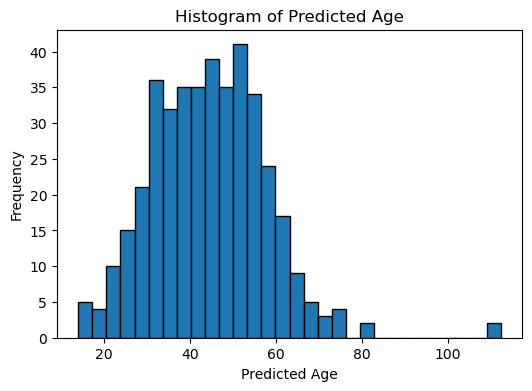

In [45]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_values, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

Correlation between predicted and AgeDeath: 0.622


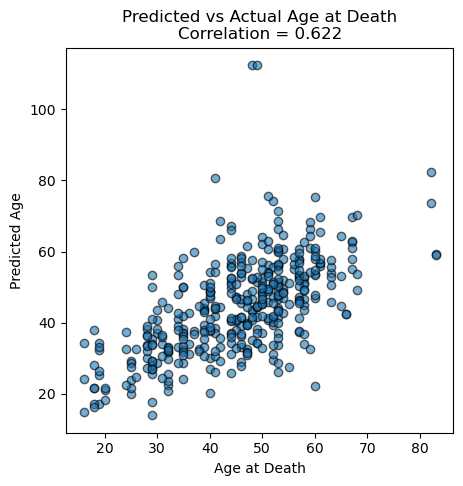

In [46]:
# Assume X_excluded has samples as rows and their index contains the sample IDs
pred = pd.Series(predicted_values.flatten(), index=X_excluded.index, name="PredictedAge")

# Align with actual ages
common_ids = pred.index.intersection(meta_scaled.index)
ages = meta_scaled.loc[common_ids, "AgeDeath"]
pred = pred.loc[common_ids]


# Correlation
corr = pred.corr(ages)
print(f"Correlation between predicted and AgeDeath: {corr:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(ages, pred, alpha=0.6, edgecolor="k")
plt.xlabel("Age at Death")
plt.ylabel("Predicted Age")
plt.title(f"Predicted vs Actual Age at Death\nCorrelation = {corr:.3f}")
plt.show()